In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load the segmented dataset
df = pd.read_csv("../data/processed/segmented_sports_injury_data.csv")
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,heart_rate,body_temperature,hydration_level,sleep_quality,recovery_score,stress_level,muscle_activity,joint_angles,gait_speed,cadence,...,training_duration,training_load,fatigue_index,injury_occurred,sport_type,gender,age,bmi,recovery_status,recovery_status_str
0,72.304051,37.048668,76.481477,5.466370,77.899691,0.375825,10.000000,126.480118,2.654327,50.000000,...,79.106564,548.417962,45.028687,0,Basketball,Female,18,25.105748,Optimal Recovery,2
1,40.000000,36.929536,72.363938,6.899090,74.845323,0.279165,310.293156,157.631630,3.431107,89.032626,...,116.954654,538.043815,42.254717,2,Basketball,Female,18,25.105748,Delayed Recovery,1
2,76.174609,36.334841,100.000000,9.574152,83.538316,0.334061,158.659094,81.766287,0.800000,73.088441,...,96.354742,647.784339,61.870056,0,Basketball,Female,18,25.105748,Optimal Recovery,2
3,100.543724,37.244474,86.172473,7.614297,79.966618,0.218766,107.079298,113.023701,1.713869,50.000000,...,97.619130,336.553431,50.268845,0,Basketball,Female,18,25.105748,Optimal Recovery,2
4,78.001235,36.510766,83.195889,5.631979,56.945979,0.484086,164.347133,112.814695,2.154233,71.288255,...,83.155527,496.076352,29.233575,2,Basketball,Female,18,25.105748,Delayed Recovery,1


In [11]:
def calculate_biological_recovery_hours(row):
    # Extract structural components
    status = row['recovery_status_str']
    score = row['recovery_score']
    
    # 1. Establish Domain-driven baseline windows (in hours) based on cohorts
    if status == 'Delayed Recovery' or status == 'Exhausted / High Strain':
        T_min, T_max = 60, 144  # Deep physiological strain requires 2.5 to 6 days
    elif status == 'Tired / Normal Fatigue':
        T_min, T_max = 30, 60   # Standard exertion requires 1.25 to 2.5 days
    else:  # 'Fresh / Ready to Train' or normal baseline
        T_min, T_max = 12, 30   # Baseline homeostatic reset requires 12 to 30 hours
        
    # 2. Normalize the raw Recovery Score feature to a [0, 1] range
    # Global min/max thresholds from the dataset profile
    score_min, score_max = 25, 98
    norm_score = (score - score_min) / (score_max - score_min)
    
    # Invert the score: Higher recovery score means LESS strain (fewer hours required)
    strain_factor = 1 - norm_score
    
    # 3. Apply Non-Linear Exponential Growth Curve
    # 'k' controls the curvature; higher values increase the penalty for high strain
    k = 2.5
    exponential_factor = (np.exp(k * strain_factor) - 1) / (np.exp(k) - 1)
    
    # Calculate localized continuous target hour metric
    recovery_hours = T_min + (exponential_factor * (T_max - T_min))
    return round(recovery_hours, 1)

In [12]:
df['recovery_time_hours'] = df.apply(calculate_biological_recovery_hours, axis=1)

In [13]:
df['recovery_time_hours'].head()

0    13.6
1    13.9
2    13.0
3    13.4
4    17.0
Name: recovery_time_hours, dtype: float64

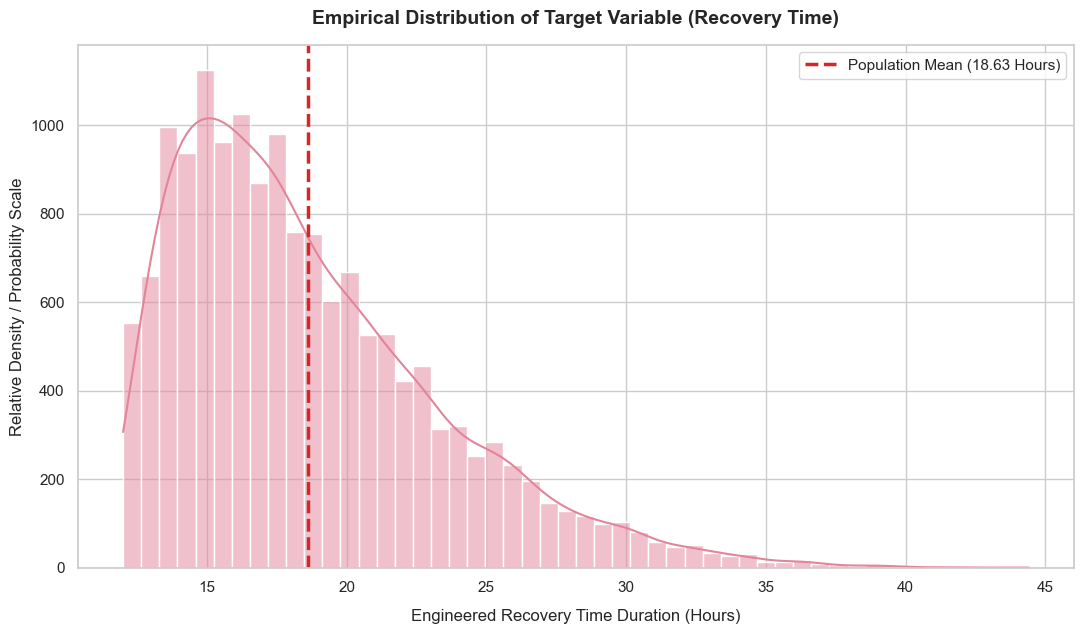

In [14]:
# Set professional visualization layout
plt.figure(figsize=(11, 6.5))
sns.set_theme(style="whitegrid")

# Calculate precise population statistical mean
mean_hours = df['recovery_time_hours'].mean()

# Plot the combined Histogram and KDE line
# bins='auto' dynamically selects optimal bin widths based on sample variance rules
ax = sns.histplot(df['recovery_time_hours'], kde=True, color='#E2849A', bins=50)

# Plot the vertical population mean indicator
plt.axvline(x=mean_hours, color='#d62728', linestyle='--', linewidth=2.5, 
            label=f'Population Mean ({mean_hours:.2f} Hours)')

# Construct a clean statistical annotations matrix box
textstr = (f"Statistical Summary:\n"
           f"Mean: {mean_hours:.2f} hrs\n"
           f"Median: {df['recovery_time_hours'].median():.1f} hrs\n"
           f"Min: {df['recovery_time_hours'].min()} hrs\n"
           f"Max: {df['recovery_time_hours'].max()} hrs")


# Layout refinement, boundary constraints, and typography setup
plt.title("Empirical Distribution of Target Variable (Recovery Time)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Engineered Recovery Time Duration (Hours)", fontsize=12, labelpad=10)
plt.ylabel("Relative Density / Probability Scale", fontsize=12)

plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/_w/m30405jx1mj3bdm7ym090rc80000gn/T/ipykernel_1658/1952611920.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='recovery_status', y='recovery_time_hours',


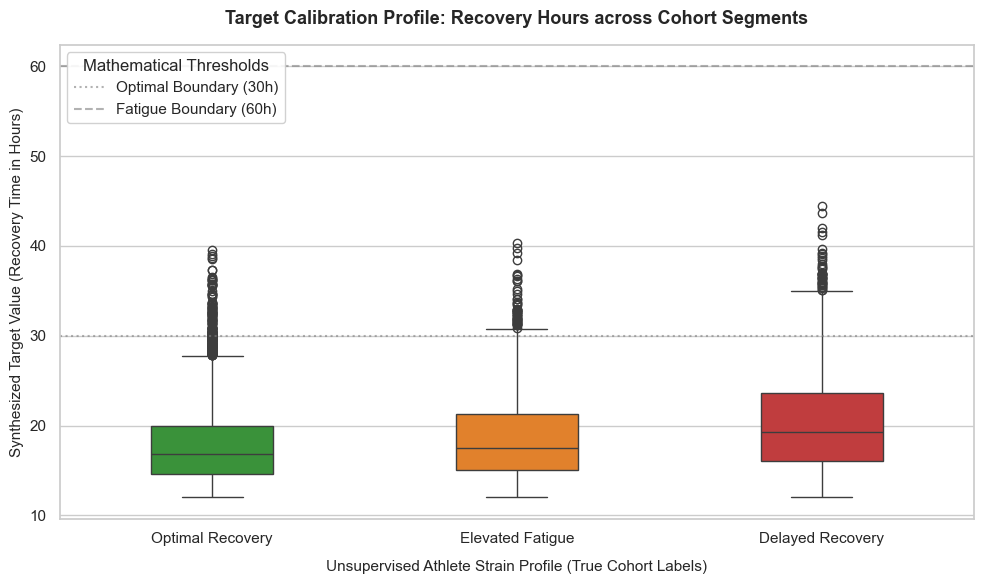

In [15]:
# Cell 12: Target Distribution Breakdown by True Cohort Labels
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Define the exact logical sequence matching your true dataset labels
group_order = ['Optimal Recovery', 'Elevated Fatigue', 'Delayed Recovery']

# Define professional status-indicative colors
cohort_colors = ['#2ca02c', '#ff7f0e', '#d62728']

# Plot the distribution using a clean Box Plot
# Using 'recovery_status' which contains your actual cohort strings
ax = sns.boxplot(data=df, x='recovery_status', y='recovery_time_hours', 
                 order=group_order, palette=cohort_colors, width=0.4)

# Overlay faint horizontal accent lines to visualize your mathematical formula thresholds
plt.axhline(y=30, color='gray', linestyle=':', alpha=0.6, label='Optimal Boundary (30h)')
plt.axhline(y=60, color='gray', linestyle='--', alpha=0.6, label='Fatigue Boundary (60h)')

# Configure typography and professional layouts
plt.title("Target Calibration Profile: Recovery Hours across Cohort Segments", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Unsupervised Athlete Strain Profile (True Cohort Labels)", fontsize=11, labelpad=10)
plt.ylabel("Synthesized Target Value (Recovery Time in Hours)", fontsize=11)

# Position our customized manual legend cleanly
plt.legend(loc='upper left', title="Mathematical Thresholds", framealpha=0.9)

plt.tight_layout()
plt.show()

In [8]:
engineered_recovery_data_save_path = "../data/processed/engineered_sports_recovery_data.csv.csv"

df.to_csv(engineered_recovery_data_save_path, index=True)